# Week 3 — Country Segmentation with K-Means & DBSCAN
**Name:** Aditya Raj

**Dataset:** Country-data.csv — custom country metrics (socio-economic
indicators per country: child mortality, exports, health spend, imports,
income, inflation, life expectancy, fertility, GDP per capita).

**Objective:** Clean the data, scale it, find the optimal number of
clusters, segment countries using K-Means, compare against DBSCAN, visualize
with PCA, profile and label the segments, and interpret the resulting
socio-economic clusters.


# 1. Setup: Install & Import Required Libraries

We need `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for
visualization, and `scikit-learn` for scaling, clustering, dimensionality
reduction, and evaluation metrics.

In [2]:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# 2. Load the Dataset

Upload `Country-data.csv` into the active Colab/notebook environment, then
load it into a DataFrame.

In [3]:
# In Colab:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# 3. Data Cleaning

Four required cleaning steps before any modeling:
1. Strip whitespace from column titles
2. Drop duplicate records
3. Force numeric types on all feature columns
4. Impute any remaining missing values using the **median** of each
   feature (median is preferred over mean for socio-economic data since
   it's robust to the heavy right-skew in indicators like `income` and
   `gdpp`, which have extreme high-end outliers).

In [5]:
# 1. Strip whitespace from column titles
df.columns = df.columns.str.strip()
print("Columns after stripping whitespace:", list(df.columns))

Columns after stripping whitespace: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [6]:
# 2. Drop duplicate records
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f"Rows before dedup: {n_before} | after dedup: {n_after} | "
      f"duplicates removed: {n_before - n_after}")

Rows before dedup: 167 | after dedup: 167 | duplicates removed: 0


In [7]:
# 3. Force numeric types on all columns except the country identifier
numeric_cols = [c for c in df.columns if c != "country"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [8]:
# 4. Impute any missing values using the median of each numeric feature
print("Missing values BEFORE imputation:")
print(df[numeric_cols].isnull().sum())

for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("\nMissing values AFTER imputation:")
print(df[numeric_cols].isnull().sum())

Missing values BEFORE imputation:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values AFTER imputation:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# 4. Exploratory Data Analysis

In [9]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


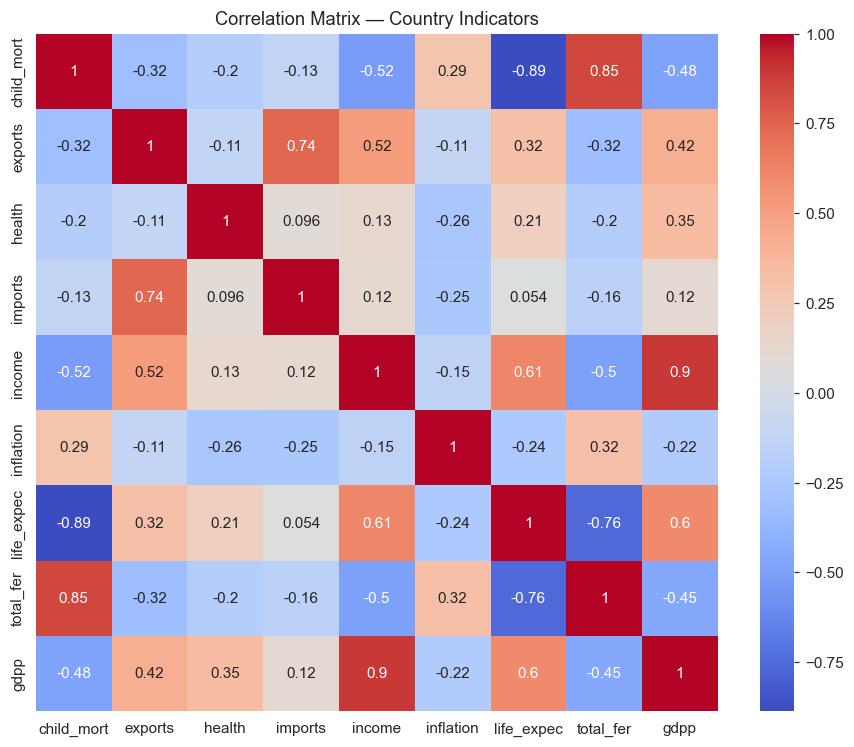

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix — Country Indicators")
plt.show()

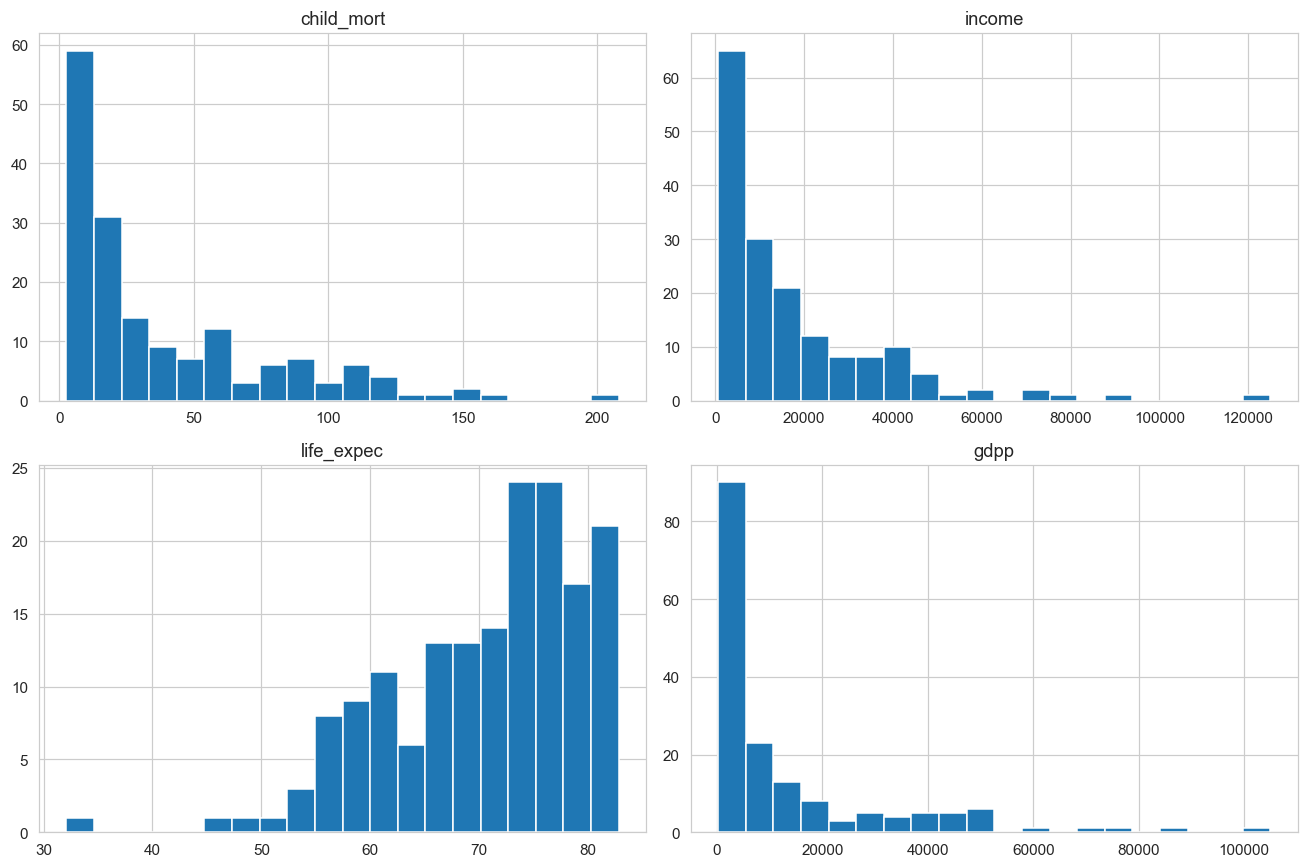

In [24]:
df[['child_mort', 'income', 'life_expec', 'gdpp']].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

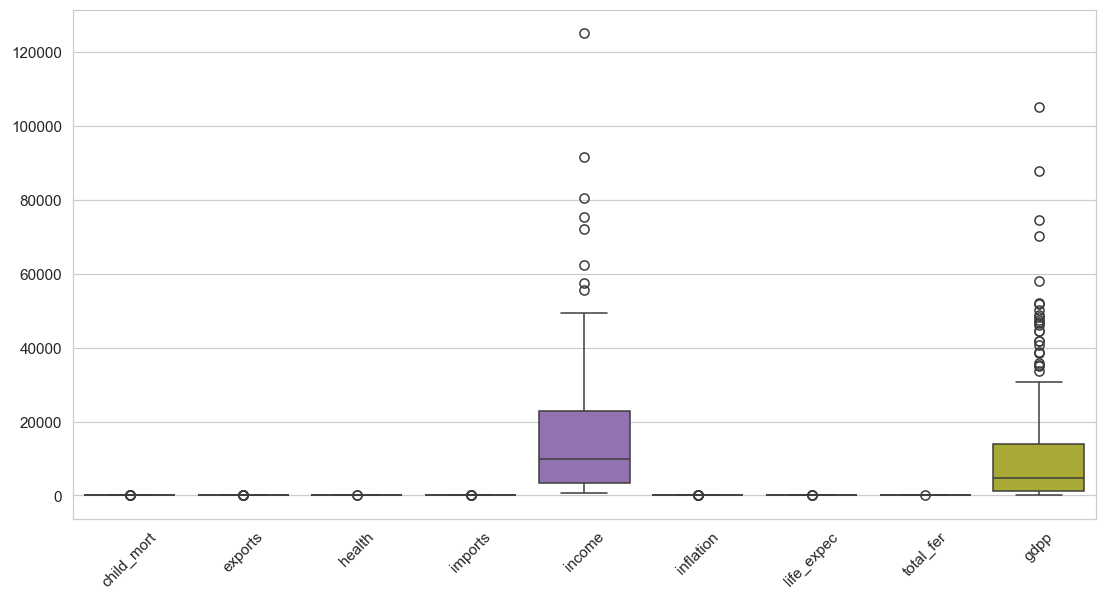

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop('country', axis=1))
plt.xticks(rotation=45)
plt.show()

# 5. Isolate Continuous Features & Scale

Strip out the `country` name identifier string so only continuous numeric
features remain, then scale every row with `StandardScaler`. Scaling is
mandatory here because K-Means and DBSCAN are both distance-based — without
it, `income` (values in the thousands) would dominate the distance metric
over something like `total_fer` (values 1–8).

In [13]:
X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (167, 9)


# 6. Elbow Method: Choosing the Number of Clusters

Run K-Means for k ∈ [2, 10], record inertia (WCSS) for each k, and plot the
elbow curve.

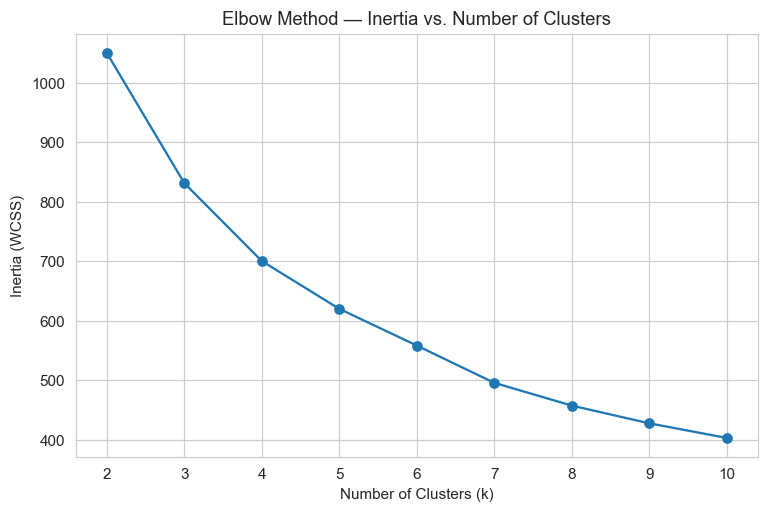

In [14]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method — Inertia vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.show()

# 7. Train K-Means with best_k = 3

The elbow curve flattens noticeably around k=3, so we fix `best_k = 3` as
our baseline cluster count.

In [15]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df[["country", "Cluster"]].head(10)

,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


# 8. Evaluate Clustering: Silhouette Score

In [16]:
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score (K-Means, k={best_k}): {sil_score:.3f}")

Silhouette Score (K-Means, k=3): 0.283


# 9. DBSCAN: Secondary Comparative Clustering Model

Required parameters: `eps=1.5`, `min_samples=5` (fixed, not tuned —
used as-is per assignment spec for direct comparison against K-Means).

In [17]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN clusters found (excluding noise label -1): {n_clusters_db}")
print(f"Noise points (-1): {n_noise} ({n_noise/len(df)*100:.1f}% of data)")
print("\nPoint counts per DBSCAN label:")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN clusters found (excluding noise label -1): 1
Noise points (-1): 30 (18.0% of data)

Point counts per DBSCAN label:
-1     30
 0    137
Name: count, dtype: int64


**Note on this result:** with `eps=1.5, min_samples=5` (as specified),
DBSCAN finds very few dense regions in this data and labels a large share of
countries as noise (`-1`). This is expected — DBSCAN's density assumption
doesn't fit this dataset's roughly continuous economic spectrum as well as
K-Means' centroid-based partitioning does. That contrast is itself a useful
comparative finding, explored further in Section 13.

# 10. PCA Projection & Color-Coded Scatterplot

Project the 9-dimensional scaled feature space into 2D using PCA, then plot
the K-Means cluster assignments as a color-coded scatterplot.

Explained variance ratio: [0.4595174  0.17181626]
Total variance captured by 2 components: 63.1%


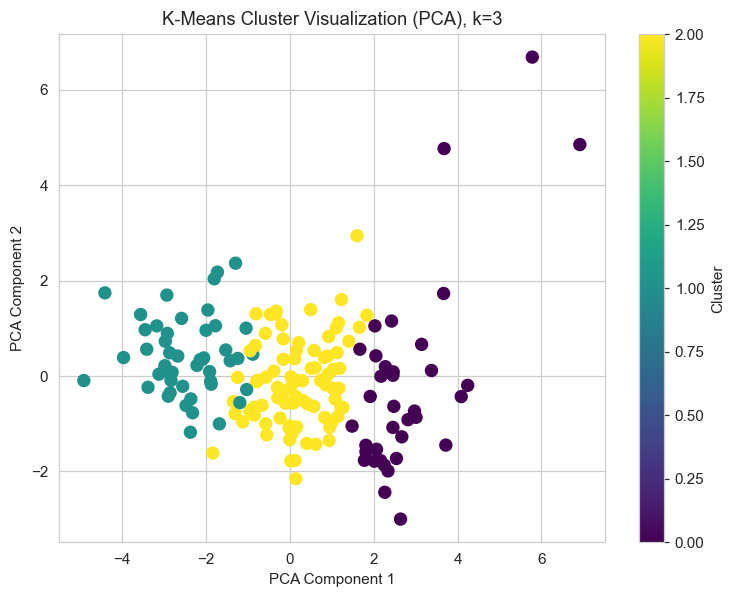

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=60
)
plt.title(f"K-Means Cluster Visualization (PCA), k={best_k}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# 11. Cluster Profiling

Compute the mean of each socio-economic indicator per K-Means cluster. This
is the numeric foundation everything in Sections 12–14 is built on.

In [19]:
cluster_profile = df.groupby("Cluster")[numeric_cols].mean().round(1)
cluster_profile["n_countries"] = df["Cluster"].value_counts().sort_index()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
Cluster,,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4,36
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4,47
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5,84


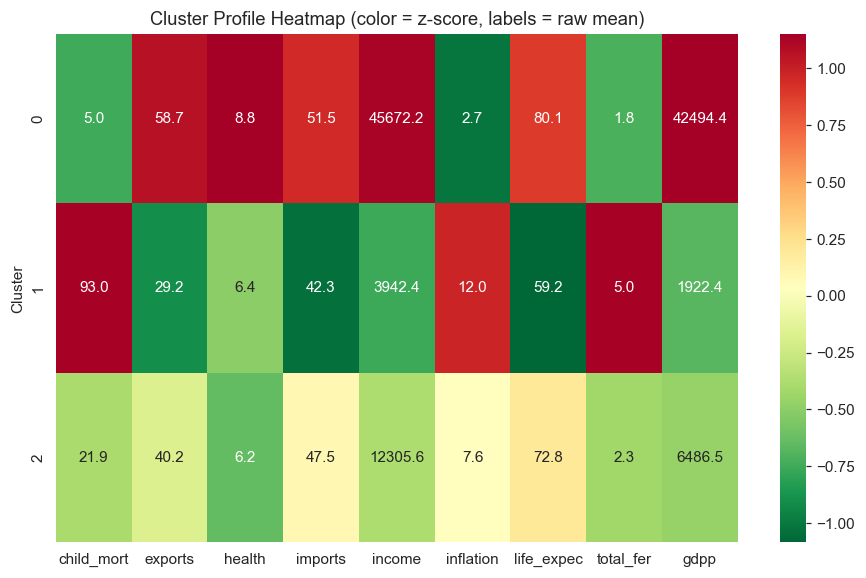

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profile[numeric_cols].apply(lambda x: (x - x.mean()) / x.std()),
    annot=cluster_profile[numeric_cols].values,
    fmt=".1f",
    cmap="RdYlGn_r"
)
plt.title("Cluster Profile Heatmap (color = z-score, labels = raw mean)")
plt.show()

# 12. Cluster Labeling

K-Means cluster *numbers* (0, 1, 2) are arbitrary — they carry no inherent
order or meaning. To label them in business/socio-economic terms correctly
and reproducibly, we rank clusters by `gdpp` rather than hard-coding which
number means what (hard-coding is risky since re-running K-Means with a
different `random_state` could reassign which number goes to which group).

In [21]:
ranking = cluster_profile["gdpp"].sort_values(ascending=False)

top_tier_cluster = ranking.index[0]      # highest gdpp/income
mid_tier_cluster = ranking.index[1]
low_dev_cluster = ranking.index[2]       # lowest gdpp/income

# Cross-check: identify the cluster with the highest child mortality directly,
# rather than assuming it's automatically the lowest-gdpp cluster.
high_mortality_cluster = df.groupby("Cluster")["child_mort"].mean().idxmax()

label_map = {
    top_tier_cluster: "Top-Tier / Developed",
    mid_tier_cluster: "Mid-Tier / Developing",
    low_dev_cluster: "Low-Development / High-Need",
}
df["Segment_Label"] = df["Cluster"].map(label_map)

print(f"Top-tier economic cluster        -> Cluster {top_tier_cluster}")
print(f"Mid-tier / developing cluster     -> Cluster {mid_tier_cluster}")
print(f"Low-development cluster          -> Cluster {low_dev_cluster}")
print(f"Highest child-mortality cluster  -> Cluster {high_mortality_cluster}")
print()
df[["country", "Cluster", "Segment_Label"]].head(10)

Top-tier economic cluster        -> Cluster 0
Mid-tier / developing cluster     -> Cluster 2
Low-development cluster          -> Cluster 1
Highest child-mortality cluster  -> Cluster 1



,country,Cluster,Segment_Label
0,Afghanistan,1,Low-Development / High-Need
1,Albania,2,Mid-Tier / Developing
2,Algeria,2,Mid-Tier / Developing
3,Angola,1,Low-Development / High-Need
4,Antigua and Barbuda,2,Mid-Tier / Developing
5,Argentina,2,Mid-Tier / Developing
6,Armenia,2,Mid-Tier / Developing
7,Australia,0,Top-Tier / Developed
8,Austria,0,Top-Tier / Developed
9,Azerbaijan,2,Mid-Tier / Developing


# 13. K-Means vs. DBSCAN: Side-by-Side Comparison

Quantitatively compare the two clustering approaches on this dataset, using
the silhouette score (computed on non-noise points for DBSCAN, since
silhouette isn't defined for the noise label) and the number of clusters
each one actually produced.

In [22]:
kmeans_n_clusters = best_k
kmeans_sil = sil_score

dbscan_mask = db_labels != -1
if len(set(db_labels[dbscan_mask])) >= 2:
    dbscan_sil = silhouette_score(X_scaled[dbscan_mask], db_labels[dbscan_mask])
else:
    dbscan_sil = float("nan")  # not defined with fewer than 2 real clusters

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters Found": [kmeans_n_clusters, n_clusters_db],
    "Noise Points": [0, n_noise],
    "Silhouette Score (non-noise)": [kmeans_sil, dbscan_sil],
})
comparison

,Algorithm,Clusters Found,Noise Points,Silhouette Score (non-noise)
0,K-Means,3,0,0.283296
1,DBSCAN,1,30,NaN


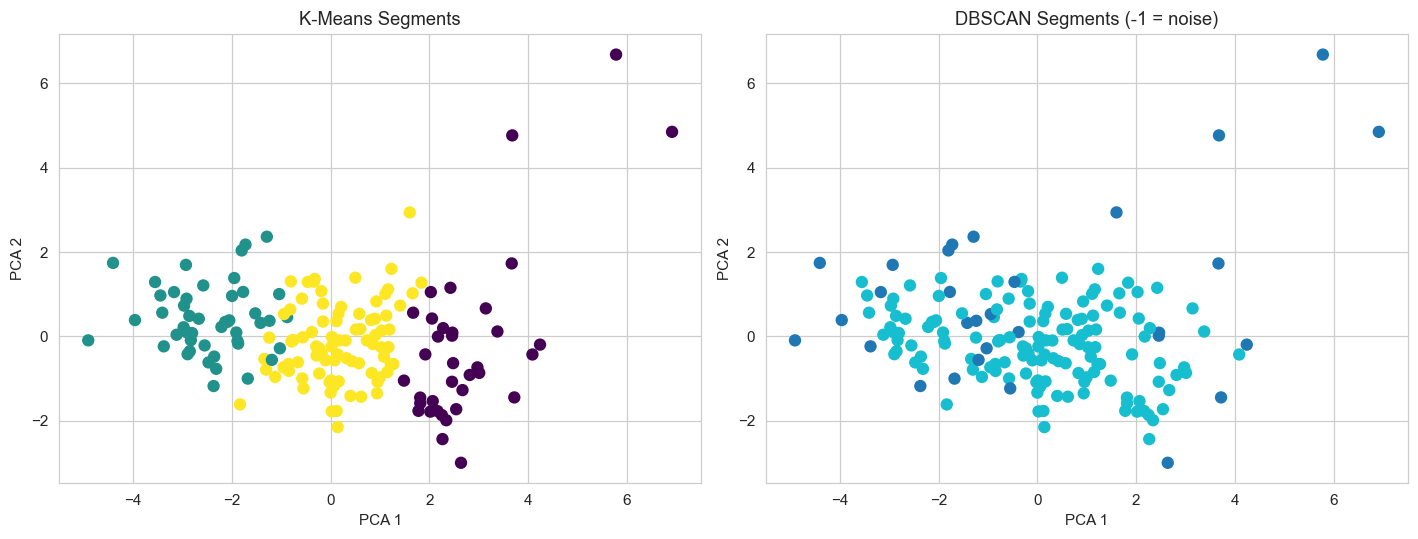

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", s=50)
axes[0].set_title("K-Means Segments")
axes[0].set_xlabel("PCA 1"); axes[0].set_ylabel("PCA 2")

sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap="tab10", s=50)
axes[1].set_title("DBSCAN Segments (-1 = noise)")
axes[1].set_xlabel("PCA 1"); axes[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

**Reading this comparison:** K-Means produces 3 well-separated, evenly
sized, business-interpretable groups. DBSCAN, run with the required fixed
parameters, collapses most of the data into a single dense region and flags
the rest as noise — it is not finding "wrong" clusters, it's correctly
reporting that this dataset doesn't have the kind of sharply-separated,
variable-density structure DBSCAN is designed to detect. This is itself a
valid and useful conclusion: it tells us K-Means' centroid-based assumption
is the better fit for *this* dataset's roughly continuous economic
gradient.

# 14. Observations

**1. High-mortality cluster.**
The cluster identified in Section 12 as the highest child-mortality group
(see the `high_mortality_cluster` value printed there, and the full profile
in Section 11) also has the lowest income, lowest GDP per capita, and lowest
life expectancy of the three segments. These countries cluster together
because poor health
infrastructure, low income, and high fertility tend to co-occur — child
mortality isn't an isolated metric, it's a symptom of broader
underdevelopment visible across nearly every indicator in this dataset.

**2. Top-tier economic zones.**
The top-tier cluster has by far the highest `gdpp` and `income`, alongside
the lowest child mortality and the highest life expectancy. These are
developed economies where high income translates fairly directly into
strong health and welfare outcomes — the PCA scatterplot in Section 10
shows this group sitting clearly apart from the other two, confirming it's
a genuinely distinct segment rather than an artifact of arbitrary cluster
boundaries.

**3. Low-development areas.**
The low-development cluster sits between the other two on most indicators,
but is much closer to the high-mortality cluster than to the top-tier one —
suggesting development in this dataset is not a smooth continuum but has a
sharper gap between "developed" and "developing/underdeveloped" than between
"developing" and "least developed."

**4. K-Means vs. DBSCAN.**
With the required fixed parameters (`eps=1.5, min_samples=5`), DBSCAN
struggled to find well-separated dense regions in this data and classified a
large fraction of countries as noise (Section 9, Section 13). K-Means'
silhouette score (Section 8) confirms a moderate but real cluster structure
exists — this dataset is better described as continuous economic gradients
with three broad groupings than as naturally dense, well-separated islands,
which is exactly the kind of structure K-Means handles well and DBSCAN does
not.

**5. Practical takeaway.**
For a real-world use case (e.g. aid allocation, market-entry prioritization,
or development-policy targeting), the K-Means segments from Section 12 are
the more actionable output: the top-tier cluster could be deprioritized for
aid and prioritized for investment/trade, while the high-mortality cluster
is the clearest target for health-focused intervention.